In [ ]:
import sys
import os

sys.path.append(os.path.abspath("/Users/clementinechazal/Documents/these/Newcastle/kgd_code"))

import numpy as np
import matplotlib.pyplot as plt
from modules.mfld import MeanFieldLangevinDynamics
from modules.kgd_functions import F_P, GradientKernel, KernelGradientDiscrepancy, k_imq,recommended_kernel,matern_kernel
import time

import jax.numpy as jnp
from jax import jit, vmap
from jax import jacfwd, jacrev
from jax.scipy.stats import multivariate_normal
import random
import jax
from jax import random
from jax.flatten_util import ravel_pytree
from jax import grad, random,vmap,tree_util
import matplotlib

In [54]:
device_name = "cpu"

In [ ]:
kernel_name = "recommended"

In [56]:
from jax import grad, random,vmap,tree_util
from jax.flatten_util import ravel_pytree

def init_params(key, input_dim, hidden_dim):
  subkey1, subkey2 = random.split(key)
  params = {
      'W1': random.normal(subkey1, (hidden_dim, input_dim)) * 1.0,
      'b1': jnp.zeros(hidden_dim),
      'W2': random.normal(subkey2, (1, hidden_dim)) * 1.0,
      'b2': jnp.zeros(1),
  }
  return params

@jit
def forward(params, z):
  h = jnp.tanh(jnp.dot(params['W1'], z) + params['b1'])  # hidden layer
  y = jnp.dot(params['W2'], h) + params['b2']             # scalar output
  return y.squeeze()

def forward_(X, z, unravel_fn):
  E = jnp.mean(jit(vmap(lambda x : forward(unravel_fn(x), z)))(X))
  return E

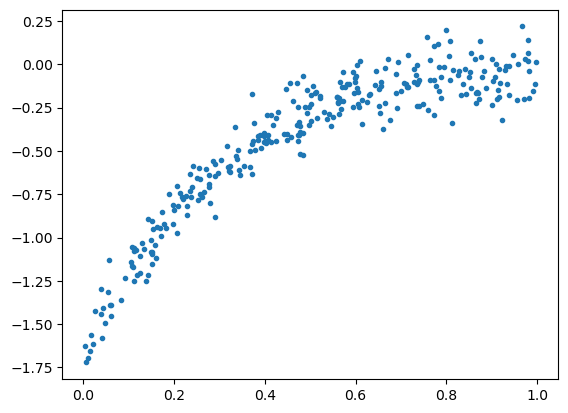

In [57]:
def generate_data(key, s, N=300, noise_std=0.1):
    key_z, key_noise = random.split(key)
    
    Z = random.uniform(key_z, (N, s),minval = 0,maxval=1.0)  # uniform distribution [0,1]

    def target_function(z):
        params = jnp.array([2, 0.5, 3, -3])
        return params[2]*jnp.tanh(params[0]*z.squeeze()+params[1]) + params[3]

    Y_clean = target_function(Z)

    # noise
    noise = noise_std * random.normal(key_noise, shape=Y_clean.shape)
    Y= Y_clean + noise

    return Z, Y

s = 1 #input dimension
key = random.PRNGKey(1003)
key, subkey = random.split(key)
N = 300
Z_train, Y_train = generate_data(subkey, s, N=N, noise_std=0.1) # put more noise
key, subkey = random.split(key)
Z_test, Y_test = generate_data(subkey, s, N=N, noise_std=0.1)

device = jax.devices()[0]
Z_train, Y_train = jax.device_put((Z_train, Y_train), device)
plt.plot(Z_train, Y_train, ".")

In [58]:

def q_0(x):
    return jnp.exp(-jnp.dot(x,x)/2) 

def grad_log_q0(X):
    return - X/0.5

def L(X, unravel_fn, Z, Y, gamma=300):
    n = len(X)
    Esp_forward = vmap(lambda z: forward_(X, z, unravel_fn))(Z)
    return gamma * jnp.mean((Esp_forward - Y) ** 2) #+ lambd * 1/n * jnp.sum(X ** 2)

# This part is required to obtain unravel_fn
hidden_dim = 1
params = init_params(key, s, hidden_dim)
params = jax.device_put(params, device)
flat_params, unravel_fn = ravel_pytree(params)

gamma = 300
L_ = lambda X: L(X, unravel_fn, Z_train, Y_train, gamma)

q_0 = jit(q_0)
L_ = jit(L_)  
 
MFLD = MeanFieldLangevinDynamics(grad_log_q0,L_)    

In [59]:
T = 20000
n = 100
eta = 1e-5
d = len(flat_params)

key, subkey = random.split(key)
X0 = 3.0*random.normal(subkey, shape=(n, d))
X0 = jax.device_put(X0, device)

all_particles = MFLD.run_particles(eta, T, X0, subkey)
X_fin = all_particles[-1]

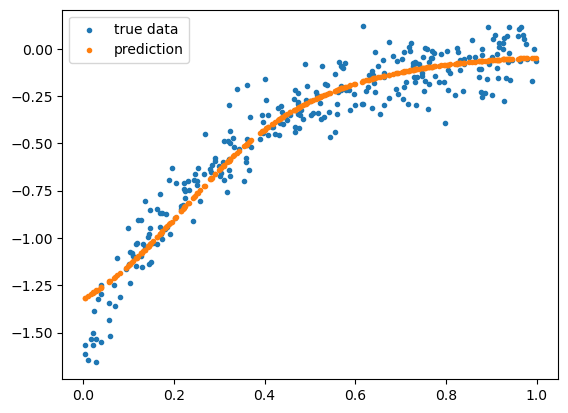

In [60]:
#Prediction function 
plt.scatter(Z_test,Y_test,label = "true data",marker = ".")
Y_hat = vmap(lambda z: forward_(X_fin, z, unravel_fn))(Z_test)
plt.scatter(Z_test,Y_hat,label = "prediction",marker = ".")
plt.legend()


Text(0, 0.5, 'dim4')

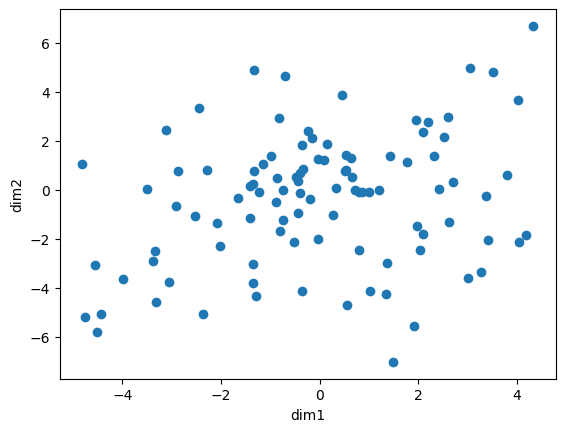

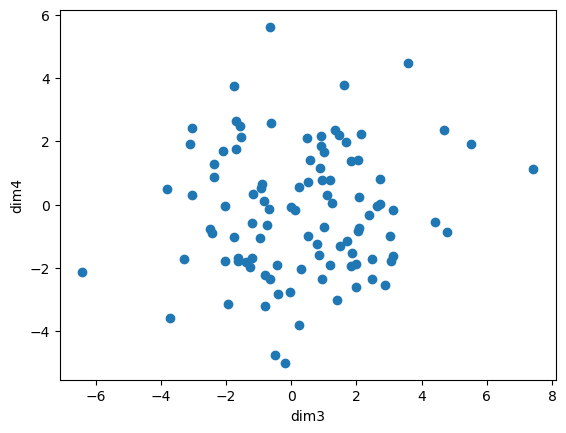

In [61]:
#Final particles positions
plt.scatter(X_fin[:,0], X_fin[:,1])
plt.xlabel("dim1")
plt.ylabel("dim2")
plt.figure()
plt.scatter(X_fin[:,2], X_fin[:,3])
plt.xlabel("dim3")
plt.ylabel("dim4")

KGD evolution

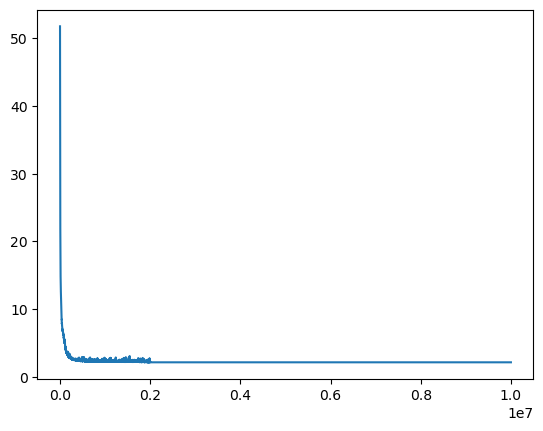

In [89]:
if kernel_name == "imq":
    scale = 0.1
    k = jit(lambda x, y: k_imq(x, y, 1, 0.5, scale))
elif kernel_name == "recommended_kernel":
    l = jit(lambda x, y: k_imq(x, y, 1, 5.0))#matern_kernel(x,y,5.0))
    alpha = 2.0
    beta = 1.0
    k = lambda x,y : recommended_kernel(x,y,l,alpha,beta,1.0)

k_pq = GradientKernel(MFLD.S_PQ,k)
KGD = KernelGradientDiscrepancy(k_pq)

KGD_values = []
for it in range(T):
    KGD_values.append(KGD.evaluate(all_particles[it]))

eval_gradL = jnp.arange(0,T)*n

plt.plot(eval_gradL,KGD_values)

In [90]:
eval_gradL[-1]/10**6

Array(9.9999, dtype=float32)

In [91]:
import jax.numpy as jnp
import pickle


expe2_filename_evol_particles = f"saved_data/expe2_evol_particles_{kernel_name}.pkl"
# load
with open(expe2_filename_evol_particles, "rb") as g:
    expe2_evol_particles = pickle.load(g)

In [92]:
iterations_gradL = jnp.array([1,10**3,10**4,10**5,2*10**6])
particles_position = all_particles[iterations_gradL//n,:,:]
expe2_evol_particles["MFLD"]["iterations_gradL"] = iterations_gradL
expe2_evol_particles["MFLD"]["particles_position"] = particles_position

In [93]:
import pickle

# Save
with open(expe2_filename_evol_particles, "wb") as gg:
    pickle.dump(expe2_evol_particles, gg)

# MFLD long running

In [ ]:
step_size = 1e-6
T = 100000

key = random.PRNGKey(42)
X0 = 3*random.normal(key, shape=(300, d))

all_particles_contour = MFLD.run_particles(step_size,T,X0,key)
X_fin_contour = all_particles[-1]

# Save Results

In [ ]:
import jax.numpy as jnp
import pickle

filename = f"saved_data/expe2_results_{kernel_name}.pkl"

# Load the file
with open(filename, "rb") as g:
    expe2_results = pickle.load(g)
    

In [ ]:
expe2_results["MFLD contour"]["X_fin"] = X_fin_contour
expe2_results["MFLD"]["X_fin"] = X_fin
expe2_results["MFLD"]["KGD_values"] = KGD_values
expe2_results["MFLD"]["gradL_eval"] = eval_gradL
expe2_results["kernel"] = kernel_name

In [ ]:
import pickle

# Save the file 
with open(filename, "wb") as gg:
    pickle.dump(expe2_results, gg)